# Online Retail EDA — Pure DuckDB Edition

A flagship exploratory-data-analysis notebook that does **everything in SQL**  
via [DuckDB](https://duckdb.org/).  Pandas is used *only* to hand data to Matplotlib for plotting.

## What makes this notebook different

| Concern | Approach |
|---|---|
| **Data loading** | DuckDB's `spatial` extension reads the `.xlsx` file directly — no `pd.read_excel` |
| **Data cleaning** | SQL `CREATE TABLE … AS SELECT` with `COALESCE`, `CASE`, and `WHERE` |
| **Aggregation & analytics** | Window functions, `DATE_TRUNC`, `DATE_PART`, CTEs |
| **Visualization** | Matplotlib on small result-sets returned by `.df()` |

## Dataset

**UCI Online Retail Dataset** (`online_retail.xlsx`)  
~542 K transaction lines from a UK-based online retailer, Dec 2010 – Dec 2011.

| Column | Description |
|---|---|
| `InvoiceNo` | 6-digit invoice number; prefix **C** = cancellation |
| `StockCode` | 5-digit product code |
| `Description` | Product name |
| `Quantity` | Quantity per transaction |
| `InvoiceDate` | Date and time of the transaction |
| `UnitPrice` | Unit price in GBP |
| `CustomerID` | 5-digit customer number |
| `Country` | Customer's country |

---
## 1 — Setup

In [1]:
try:
    import duckdb
except ImportError:
    %pip install duckdb --quiet
    import duckdb

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── visual defaults ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 110,
})

COLORS = {
    "bar":   "#4C72B0",
    "line":  "#DD8452",
    "accent": "#55A868",
    "cancel": "#C44E52",
}

print(f"DuckDB {duckdb.__version__}  ✓")

DuckDB 1.5.2  ✓


---
## 2 — Load the Excel file *directly* into DuckDB

DuckDB's **`spatial`** extension ships an XLSX/ODS reader (`st_read`).  
No pandas, no openpyxl — one SQL statement.

In [2]:
con = duckdb.connect("online_retail.duckdb")

# install the spatial extension (only needed once per database)
con.execute("INSTALL spatial; LOAD spatial;")

# drop any prior copy so the notebook is re-runnable
con.execute("DROP TABLE IF EXISTS raw")

con.execute("""
    CREATE TABLE raw AS
    SELECT *
    FROM st_read(
            'online_retail.xlsx',
            layer = 'Online Retail',
            open_options = ['HEADERS=FORCE']
         )
""")

row_count = con.execute("SELECT COUNT(*) FROM raw").fetchone()[0]
print(f"Loaded {row_count:,} rows from online_retail.xlsx")

Loaded 541,909 rows from online_retail.xlsx


---
## 3 — Schema inspection

In [3]:
con.sql("DESCRIBE raw").show()

┌─────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │ column_type  │  null   │   key   │ default │  extra  │
│   varchar   │   varchar    │ varchar │ varchar │ varchar │ varchar │
├─────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ OGC_FID     │ BIGINT       │ YES     │ NULL    │ NULL    │ NULL    │
│ InvoiceNo   │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ StockCode   │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ Description │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ Quantity    │ INTEGER      │ YES     │ NULL    │ NULL    │ NULL    │
│ InvoiceDate │ TIMESTAMP_MS │ YES     │ NULL    │ NULL    │ NULL    │
│ UnitPrice   │ DOUBLE       │ YES     │ NULL    │ NULL    │ NULL    │
│ CustomerID  │ INTEGER      │ YES     │ NULL    │ NULL    │ NULL    │
│ Country     │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴──────────────┴─────────┴─────────┴─────────┴─────────┘



In [4]:
con.sql("SELECT * FROM raw LIMIT 5").show()

┌─────────┬───────────┬───────────┬─────────────────────────────────────┬──────────┬─────────────────────┬───────────┬────────────┬────────────────┐
│ OGC_FID │ InvoiceNo │ StockCode │             Description             │ Quantity │     InvoiceDate     │ UnitPrice │ CustomerID │    Country     │
│  int64  │  varchar  │  varchar  │               varchar               │  int32   │    timestamp_ms     │  double   │   int32    │    varchar     │
├─────────┼───────────┼───────────┼─────────────────────────────────────┼──────────┼─────────────────────┼───────────┼────────────┼────────────────┤
│       2 │ 536365    │ 85123A    │ WHITE HANGING HEART T-LIGHT HOLDER  │        6 │ 2010-12-01 08:26:00 │      2.55 │      17850 │ United Kingdom │
│       3 │ 536365    │ 71053     │ WHITE METAL LANTERN                 │        6 │ 2010-12-01 08:26:00 │      3.39 │      17850 │ United Kingdom │
│       4 │ 536365    │ 84406B    │ CREAM CUPID HEARTS COAT HANGER      │        8 │ 2010-12-01 08:26:00 │

---
## 4 — Missing-value audit (all columns)

In [5]:
con.sql("""
    WITH counts AS (
        SELECT
            COUNT(*)                                              AS total_rows,
            SUM(CASE WHEN InvoiceNo   IS NULL THEN 1 ELSE 0 END) AS InvoiceNo,
            SUM(CASE WHEN StockCode   IS NULL THEN 1 ELSE 0 END) AS StockCode,
            SUM(CASE WHEN Description IS NULL THEN 1 ELSE 0 END) AS Description,
            SUM(CASE WHEN Quantity    IS NULL THEN 1 ELSE 0 END) AS Quantity,
            SUM(CASE WHEN InvoiceDate IS NULL THEN 1 ELSE 0 END) AS InvoiceDate,
            SUM(CASE WHEN UnitPrice   IS NULL THEN 1 ELSE 0 END) AS UnitPrice,
            SUM(CASE WHEN CustomerID  IS NULL THEN 1 ELSE 0 END) AS CustomerID,
            SUM(CASE WHEN Country     IS NULL THEN 1 ELSE 0 END) AS Country
        FROM raw
    )
    UNPIVOT counts
    ON InvoiceNo, StockCode, Description, Quantity,
       InvoiceDate, UnitPrice, CustomerID, Country
    INTO
        NAME column_name
        VALUE null_count
""").show()

# Also show the total row count for context
total = con.execute("SELECT COUNT(*) FROM raw").fetchone()[0]
print(f"\nTotal rows: {total:,}")

┌────────────┬─────────────┬────────────┐
│ total_rows │ column_name │ null_count │
│   int64    │   varchar   │   int128   │
├────────────┼─────────────┼────────────┤
│     541909 │ InvoiceNo   │          0 │
│     541909 │ StockCode   │          0 │
│     541909 │ Description │       1454 │
│     541909 │ Quantity    │          0 │
│     541909 │ InvoiceDate │          0 │
│     541909 │ UnitPrice   │          0 │
│     541909 │ CustomerID  │     135080 │
│     541909 │ Country     │          0 │
└────────────┴─────────────┴────────────┘


Total rows: 541,909


In [6]:
# missing-value percentages — easier to scan
con.sql("""
    SELECT
        ROUND(100.0 * SUM(CASE WHEN Description IS NULL THEN 1 ELSE 0 END)
              / COUNT(*), 2)  AS pct_null_Description,
        ROUND(100.0 * SUM(CASE WHEN CustomerID  IS NULL THEN 1 ELSE 0 END)
              / COUNT(*), 2)  AS pct_null_CustomerID
    FROM raw
""").show()

┌──────────────────────┬─────────────────────┐
│ pct_null_Description │ pct_null_CustomerID │
│        double        │       double        │
├──────────────────────┼─────────────────────┤
│                 0.27 │               24.93 │
└──────────────────────┴─────────────────────┘



**Take-away:** `CustomerID` is missing in ~25 % of rows; `Description` in ~0.3 %.  
All other columns are fully populated.

---
## 5 — Descriptive statistics (SQL-only)

In [7]:
con.sql("""
    SELECT
        -- Quantity
        MIN(Quantity)                        AS qty_min,
        PERCENTILE_CONT(0.25) WITHIN GROUP
            (ORDER BY Quantity)              AS qty_q1,
        MEDIAN(Quantity)                     AS qty_median,
        ROUND(AVG(Quantity), 2)              AS qty_mean,
        PERCENTILE_CONT(0.75) WITHIN GROUP
            (ORDER BY Quantity)              AS qty_q3,
        MAX(Quantity)                        AS qty_max,
        -- UnitPrice
        MIN(UnitPrice)                       AS price_min,
        ROUND(MEDIAN(UnitPrice), 2)          AS price_median,
        ROUND(AVG(UnitPrice), 2)             AS price_mean,
        MAX(UnitPrice)                       AS price_max
    FROM raw
""").show()

┌─────────┬────────┬────────────┬──────────┬────────┬─────────┬───────────┬──────────────┬────────────┬───────────┐
│ qty_min │ qty_q1 │ qty_median │ qty_mean │ qty_q3 │ qty_max │ price_min │ price_median │ price_mean │ price_max │
│  int32  │ double │   double   │  double  │ double │  int32  │  double   │    double    │   double   │  double   │
├─────────┼────────┼────────────┼──────────┼────────┼─────────┼───────────┼──────────────┼────────────┼───────────┤
│  -80995 │    1.0 │        3.0 │     9.55 │   10.0 │   80995 │ -11062.06 │         2.08 │       4.61 │   38970.0 │
└─────────┴────────┴────────────┴──────────┴────────┴─────────┴───────────┴──────────────┴────────────┴───────────┘



Negative quantities are *cancellations* (invoice numbers prefixed with **C**).  
Zero or negative unit prices are test/adjustment rows.  
We will separate these in the cleaned table.

---
## 6 — Cancellation overview

Before we clean, let's quantify cancellations.

In [8]:
con.sql("""
    SELECT
        CASE WHEN InvoiceNo LIKE 'C%' THEN 'Cancelled' ELSE 'Normal' END AS order_type,
        COUNT(*)                               AS rows,
        COUNT(DISTINCT InvoiceNo)              AS invoices,
        ROUND(SUM(Quantity * UnitPrice), 2)    AS gross_value
    FROM raw
    GROUP BY order_type
    ORDER BY order_type
""").show()

┌────────────┬────────┬──────────┬─────────────┐
│ order_type │  rows  │ invoices │ gross_value │
│  varchar   │ int64  │  int64   │   double    │
├────────────┼────────┼──────────┼─────────────┤
│ Cancelled  │   9288 │     3836 │  -896812.49 │
│ Normal     │ 532621 │    22064 │ 10644560.42 │
└────────────┴────────┴──────────┴─────────────┘



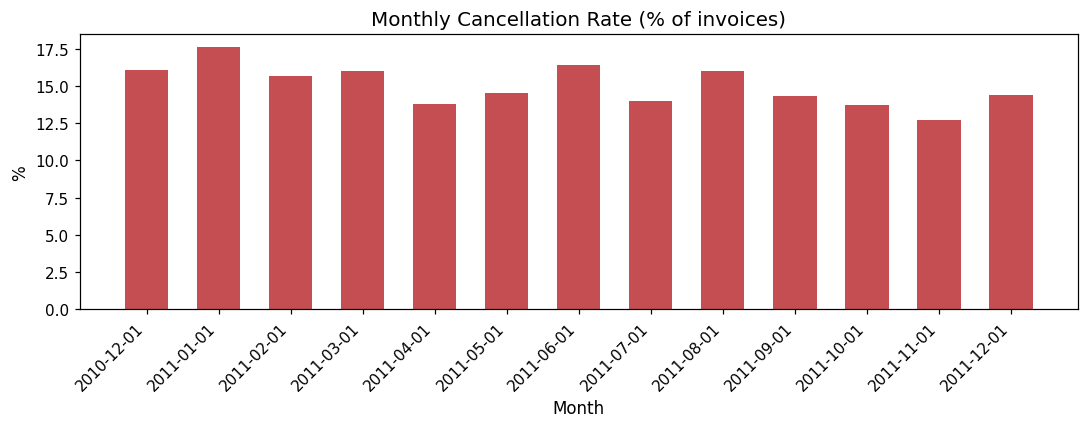

In [9]:
# cancellation rate by month
df_cancel = con.sql("""
    SELECT
        DATE_TRUNC('month', InvoiceDate)::DATE   AS month,
        COUNT(DISTINCT InvoiceNo) FILTER
            (WHERE InvoiceNo LIKE 'C%')          AS cancelled_invoices,
        COUNT(DISTINCT InvoiceNo) FILTER
            (WHERE InvoiceNo NOT LIKE 'C%')      AS normal_invoices
    FROM raw
    GROUP BY month
    ORDER BY month
""").df()

df_cancel["cancel_rate_pct"] = (
    100 * df_cancel["cancelled_invoices"]
    / (df_cancel["cancelled_invoices"] + df_cancel["normal_invoices"])
).round(1)

fig, ax = plt.subplots()
ax.bar(df_cancel["month"].astype(str), df_cancel["cancel_rate_pct"],
       color=COLORS["cancel"], width=0.6)
ax.set_title("Monthly Cancellation Rate (% of invoices)")
ax.set_ylabel("%")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 7 — Build the cleaned table

Rules applied:

1. Keep only **non-cancelled** rows (`InvoiceNo` does NOT start with `C`)
2. `Quantity > 0` and `UnitPrice > 0`
3. Fill missing `Description` → `'Unknown'`
4. Cast `CustomerID` to `INTEGER` (fill missing → `0`)
5. Add a computed `TotalPrice` column

In [10]:
con.execute("DROP TABLE IF EXISTS clean")

con.execute("""
    CREATE TABLE clean AS
    SELECT
        InvoiceNo,
        StockCode,
        COALESCE(Description, 'Unknown')              AS Description,
        Quantity,
        InvoiceDate,
        UnitPrice,
        ROUND(Quantity * UnitPrice, 2)                 AS TotalPrice,
        COALESCE(CAST(CustomerID AS INTEGER), 0)       AS CustomerID,
        Country,
        -- derived time dimensions
        CAST(InvoiceDate AS DATE)                      AS InvoiceDay,
        DATE_TRUNC('month', InvoiceDate)::DATE         AS InvoiceMonth,
        EXTRACT(DOW  FROM InvoiceDate)                 AS DayOfWeek,   -- 0=Sun
        EXTRACT(HOUR FROM InvoiceDate)                 AS HourOfDay
    FROM raw
    WHERE InvoiceNo NOT LIKE 'C%'
      AND Quantity  > 0
      AND UnitPrice > 0
""")

con.sql("""
    SELECT
        COUNT(*)                   AS rows,
        COUNT(DISTINCT InvoiceNo)  AS invoices,
        COUNT(DISTINCT CustomerID) AS customers,
        COUNT(DISTINCT StockCode)  AS products,
        COUNT(DISTINCT Country)    AS countries,
        MIN(InvoiceDate)::DATE     AS first_date,
        MAX(InvoiceDate)::DATE     AS last_date
    FROM clean
""").show()

┌────────┬──────────┬───────────┬──────────┬───────────┬────────────┬────────────┐
│  rows  │ invoices │ customers │ products │ countries │ first_date │ last_date  │
│ int64  │  int64   │   int64   │  int64   │   int64   │    date    │    date    │
├────────┼──────────┼───────────┼──────────┼───────────┼────────────┼────────────┤
│ 530104 │    19960 │      4339 │     3922 │        38 │ 2010-12-01 │ 2011-12-09 │
└────────┴──────────┴───────────┴──────────┴───────────┴────────────┴────────────┘



In [11]:
con.sql("SELECT * FROM clean LIMIT 5").show()

┌───────────┬───────────┬─────────────────────────────────────┬──────────┬─────────────────────┬───────────┬────────────┬────────────┬────────────────┬────────────┬──────────────┬───────────┬───────────┐
│ InvoiceNo │ StockCode │             Description             │ Quantity │     InvoiceDate     │ UnitPrice │ TotalPrice │ CustomerID │    Country     │ InvoiceDay │ InvoiceMonth │ DayOfWeek │ HourOfDay │
│  varchar  │  varchar  │               varchar               │  int32   │    timestamp_ms     │  double   │   double   │   int32    │    varchar     │    date    │     date     │   int64   │   int64   │
├───────────┼───────────┼─────────────────────────────────────┼──────────┼─────────────────────┼───────────┼────────────┼────────────┼────────────────┼────────────┼──────────────┼───────────┼───────────┤
│ 536365    │ 85123A    │ WHITE HANGING HEART T-LIGHT HOLDER  │        6 │ 2010-12-01 08:26:00 │      2.55 │       15.3 │      17850 │ United Kingdom │ 2010-12-01 │ 2010-12-01   │     

---
## 8 — Revenue overview

In [12]:
con.sql("""
    SELECT
        ROUND(SUM(TotalPrice), 2)              AS total_revenue,
        ROUND(AVG(TotalPrice), 2)              AS avg_line_revenue,
        ROUND(MEDIAN(TotalPrice), 2)           AS median_line_revenue,
        COUNT(DISTINCT InvoiceNo)              AS total_invoices,
        ROUND(SUM(TotalPrice)
              / COUNT(DISTINCT InvoiceNo), 2)  AS avg_order_value
    FROM clean
""").show()

┌───────────────┬──────────────────┬─────────────────────┬────────────────┬─────────────────┐
│ total_revenue │ avg_line_revenue │ median_line_revenue │ total_invoices │ avg_order_value │
│    double     │      double      │       double        │     int64      │     double      │
├───────────────┼──────────────────┼─────────────────────┼────────────────┼─────────────────┤
│   10666684.54 │            20.12 │                 9.9 │          19960 │           534.4 │
└───────────────┴──────────────────┴─────────────────────┴────────────────┴─────────────────┘



---
## 9 — Monthly revenue trend

In [13]:
df_monthly = con.sql("""
    SELECT
        InvoiceMonth                                    AS month,
        ROUND(SUM(TotalPrice), 2)                       AS revenue,
        COUNT(DISTINCT InvoiceNo)                       AS orders,
        COUNT(DISTINCT CustomerID)                      AS unique_customers,
        -- month-over-month growth
        ROUND(100.0 * (SUM(TotalPrice)
              - LAG(SUM(TotalPrice)) OVER (ORDER BY InvoiceMonth))
              / LAG(SUM(TotalPrice)) OVER (ORDER BY InvoiceMonth), 1
        ) AS mom_growth_pct
    FROM clean
    GROUP BY InvoiceMonth
    ORDER BY InvoiceMonth
""").df()

df_monthly

,month,revenue,orders,unique_customers,mom_growth_pct
0,2010-12-01,823746.14,1559,886,NaN
1,2011-01-01,691364.56,1086,742,-16.1
2,2011-02-01,523631.89,1100,759,-24.3
3,2011-03-01,717639.36,1454,975,37.1
4,2011-04-01,537808.62,1246,857,-25.1
5,2011-05-01,770536.02,1681,1057,43.3
6,2011-06-01,761739.90,1533,992,-1.1
7,2011-07-01,719221.19,1475,950,-5.6
8,2011-08-01,759138.38,1361,936,5.6
9,2011-09-01,1058590.17,1837,1267,39.4


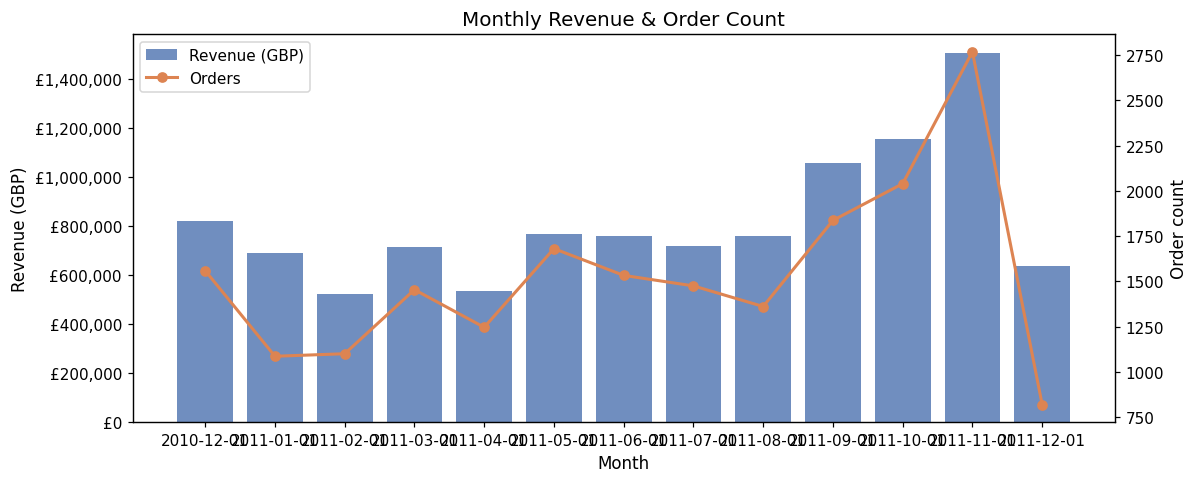

In [14]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))

ax1.bar(df_monthly["month"].astype(str), df_monthly["revenue"],
        color=COLORS["bar"], alpha=0.8, label="Revenue (GBP)")
ax1.set_ylabel("Revenue (GBP)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(df_monthly["month"].astype(str), df_monthly["orders"],
         color=COLORS["line"], marker="o", linewidth=2, label="Orders")
ax2.set_ylabel("Order count")

ax1.set_title("Monthly Revenue & Order Count")
ax1.set_xlabel("Month")
plt.xticks(rotation=45, ha="right")

# combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
plt.show()

---
## 10 — Top 10 countries by revenue

In [15]:
df_country = con.sql("""
    SELECT
        Country,
        ROUND(SUM(TotalPrice), 2)        AS revenue,
        COUNT(DISTINCT InvoiceNo)         AS orders,
        COUNT(DISTINCT CustomerID)        AS customers,
        ROUND(SUM(TotalPrice)
              / COUNT(DISTINCT InvoiceNo), 2) AS avg_order_value
    FROM clean
    GROUP BY Country
    ORDER BY revenue DESC
    LIMIT 10
""").df()

df_country

,Country,revenue,orders,customers,avg_order_value
0,United Kingdom,9025222.08,18019,3921,500.87
1,Netherlands,285446.34,94,9,3036.66
2,EIRE,283453.96,288,4,984.22
3,Germany,228867.14,457,94,500.80
4,France,209715.11,392,88,534.99
5,Australia,138521.31,57,9,2430.20
6,Spain,61577.11,90,30,684.19
7,Switzerland,57089.90,54,22,1057.22
8,Belgium,41196.34,98,25,420.37
9,Sweden,38378.33,36,8,1066.06


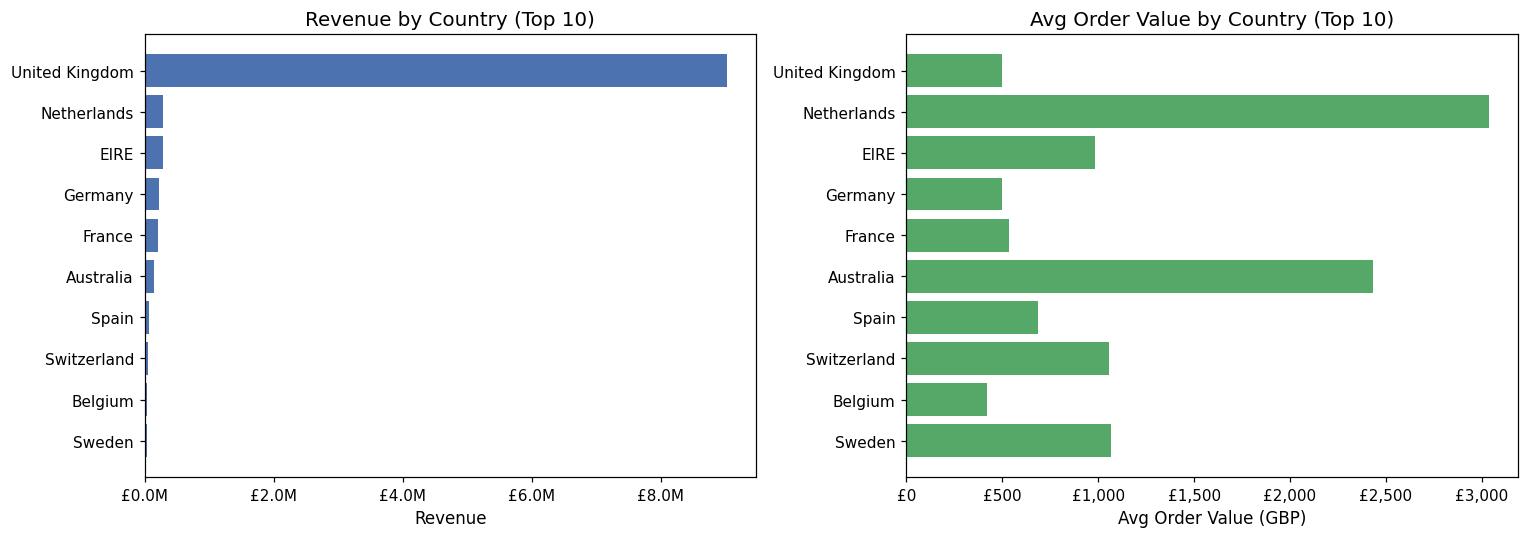

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# revenue
ax1.barh(df_country["Country"][::-1], df_country["revenue"][::-1],
         color=COLORS["bar"])
ax1.set_title("Revenue by Country (Top 10)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax1.set_xlabel("Revenue")

# avg order value
ax2.barh(df_country["Country"][::-1], df_country["avg_order_value"][::-1],
         color=COLORS["accent"])
ax2.set_title("Avg Order Value by Country (Top 10)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax2.set_xlabel("Avg Order Value (GBP)")

plt.tight_layout()
plt.show()

---
## 11 — Top 15 products by quantity sold

In [17]:
df_products = con.sql("""
    SELECT
        Description,
        SUM(Quantity)                      AS total_qty,
        ROUND(SUM(TotalPrice), 2)          AS revenue,
        COUNT(DISTINCT InvoiceNo)          AS times_ordered
    FROM clean
    WHERE Description != 'Unknown'
    GROUP BY Description
    ORDER BY total_qty DESC
    LIMIT 15
""").df()

df_products

,Description,total_qty,revenue,times_ordered
0,"PAPER CRAFT , LITTLE BIRDIE",80995.0,168469.60,1
1,MEDIUM CERAMIC TOP STORAGE JAR,78033.0,81700.92,247
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047.0,13841.85,535
3,JUMBO BAG RED RETROSPOT,48474.0,94340.05,2089
4,WHITE HANGING HEART T-LIGHT HOLDER,37891.0,106292.77,2256
5,POPCORN HOLDER,36761.0,34298.87,803
6,ASSORTED COLOUR BIRD ORNAMENT,36461.0,59094.93,1455
7,PACK OF 72 RETROSPOT CAKE CASES,36419.0,21259.10,1320
8,RABBIT NIGHT LIGHT,30788.0,66964.99,994
9,MINI PAINT SET VINTAGE,26633.0,16937.82,380


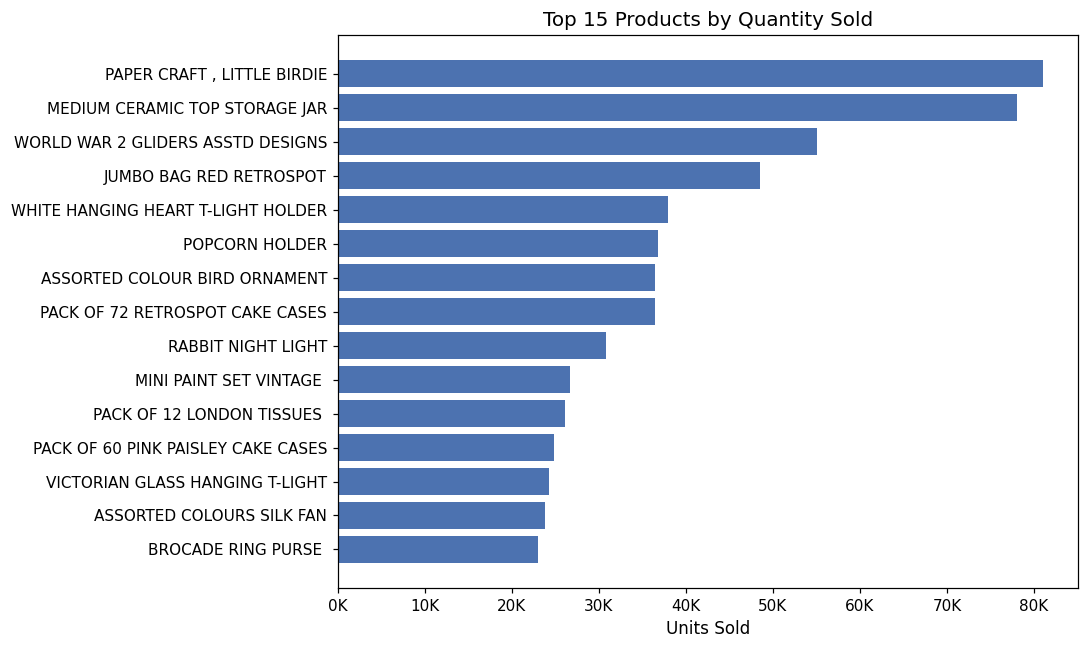

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_products["Description"][::-1], df_products["total_qty"][::-1],
        color=COLORS["bar"])
ax.set_title("Top 15 Products by Quantity Sold")
ax.set_xlabel("Units Sold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

---
## 12 — Top 15 products by *revenue*

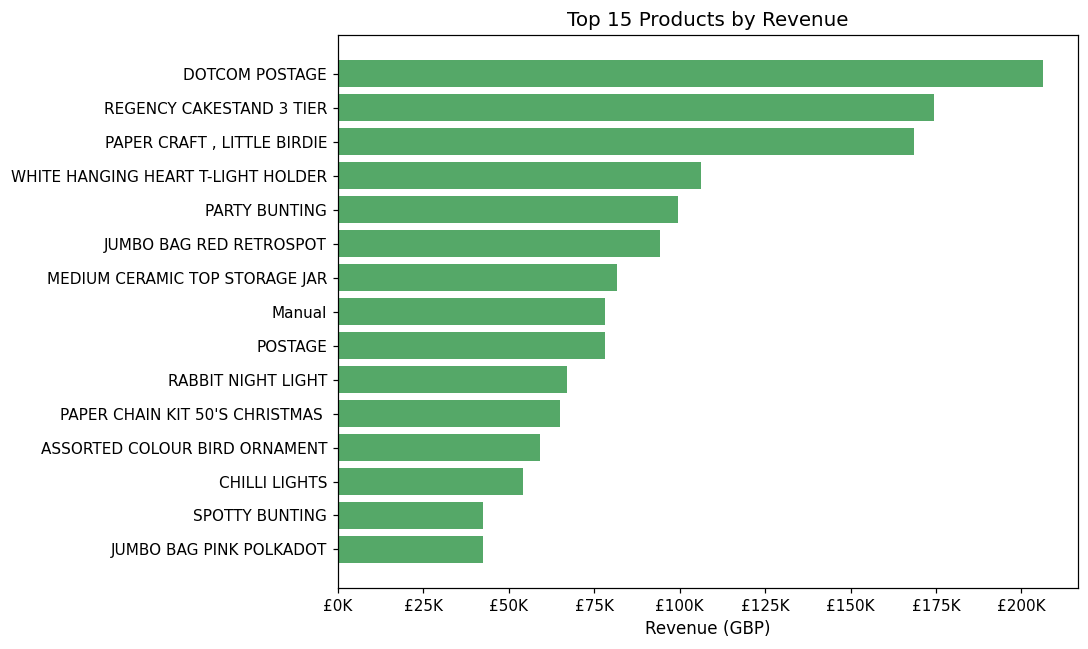

In [19]:
df_rev_prod = con.sql("""
    SELECT
        Description,
        ROUND(SUM(TotalPrice), 2) AS revenue,
        SUM(Quantity)              AS total_qty
    FROM clean
    WHERE Description != 'Unknown'
    GROUP BY Description
    ORDER BY revenue DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_rev_prod["Description"][::-1], df_rev_prod["revenue"][::-1],
        color=COLORS["accent"])
ax.set_title("Top 15 Products by Revenue")
ax.set_xlabel("Revenue (GBP)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

---
## 13 — Temporal patterns: day-of-week & hour-of-day

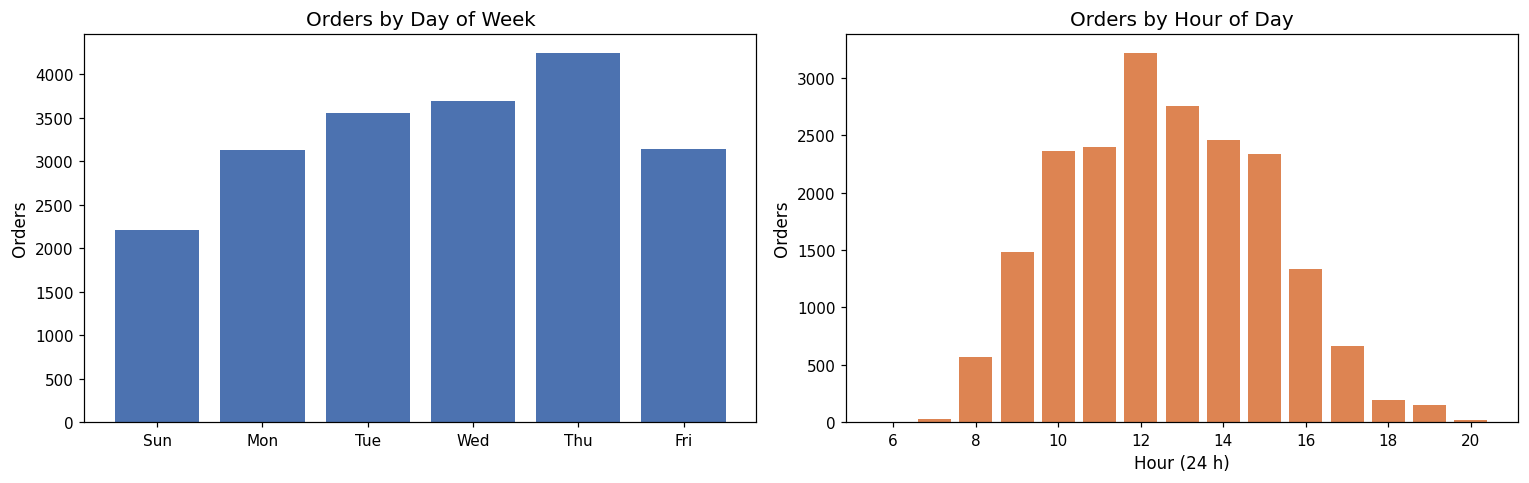

In [20]:
df_dow = con.sql("""
    SELECT
        DayOfWeek,
        CASE DayOfWeek
            WHEN 0 THEN 'Sun' WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue'
            WHEN 3 THEN 'Wed' WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri'
            WHEN 6 THEN 'Sat'
        END AS day_name,
        COUNT(DISTINCT InvoiceNo)      AS orders,
        ROUND(SUM(TotalPrice), 2)      AS revenue
    FROM clean
    GROUP BY DayOfWeek
    ORDER BY DayOfWeek
""").df()

df_hour = con.sql("""
    SELECT
        HourOfDay,
        COUNT(DISTINCT InvoiceNo)      AS orders,
        ROUND(SUM(TotalPrice), 2)      AS revenue
    FROM clean
    GROUP BY HourOfDay
    ORDER BY HourOfDay
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.bar(df_dow["day_name"], df_dow["orders"], color=COLORS["bar"])
ax1.set_title("Orders by Day of Week")
ax1.set_ylabel("Orders")

ax2.bar(df_hour["HourOfDay"].astype(int), df_hour["orders"], color=COLORS["line"])
ax2.set_title("Orders by Hour of Day")
ax2.set_xlabel("Hour (24 h)")
ax2.set_ylabel("Orders")

plt.tight_layout()
plt.show()

---
## 14 — Basket-size analysis

How many distinct line items does a typical invoice contain?

In [21]:
con.sql("""
    WITH basket AS (
        SELECT
            InvoiceNo,
            COUNT(*)                  AS line_items,
            SUM(Quantity)             AS total_units,
            ROUND(SUM(TotalPrice), 2) AS basket_value
        FROM clean
        GROUP BY InvoiceNo
    )
    SELECT
        ROUND(AVG(line_items), 1)     AS avg_line_items,
        MEDIAN(line_items)            AS median_line_items,
        MAX(line_items)               AS max_line_items,
        ROUND(AVG(total_units), 1)    AS avg_units,
        ROUND(AVG(basket_value), 2)   AS avg_basket_value,
        ROUND(MEDIAN(basket_value), 2) AS median_basket_value
    FROM basket
""").show()

┌────────────────┬───────────────────┬────────────────┬───────────┬──────────────────┬─────────────────────┐
│ avg_line_items │ median_line_items │ max_line_items │ avg_units │ avg_basket_value │ median_basket_value │
│     double     │      double       │     int64      │  double   │      double      │       double        │
├────────────────┼───────────────────┼────────────────┼───────────┼──────────────────┼─────────────────────┤
│           26.6 │              15.0 │           1114 │     280.0 │            534.4 │              303.83 │
└────────────────┴───────────────────┴────────────────┴───────────┴──────────────────┴─────────────────────┘



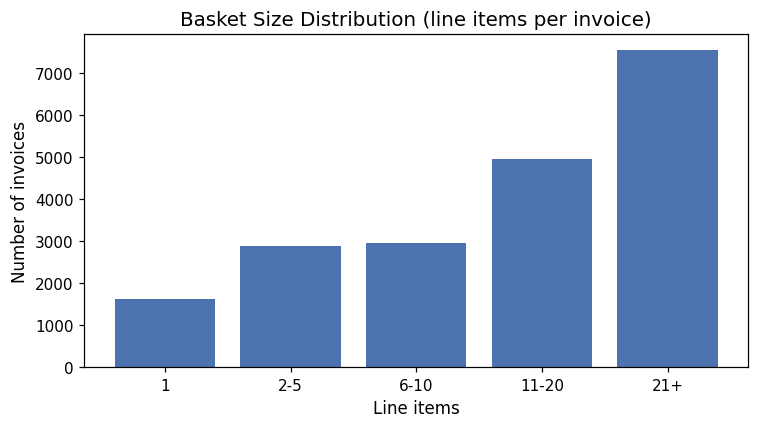

In [22]:
df_basket = con.sql("""
    WITH basket AS (
        SELECT InvoiceNo,
               COUNT(*) AS line_items
        FROM clean
        GROUP BY InvoiceNo
    )
    SELECT
        CASE
            WHEN line_items = 1        THEN '1'
            WHEN line_items BETWEEN 2  AND 5  THEN '2-5'
            WHEN line_items BETWEEN 6  AND 10 THEN '6-10'
            WHEN line_items BETWEEN 11 AND 20 THEN '11-20'
            ELSE '21+'
        END AS bucket,
        COUNT(*) AS invoices
    FROM basket
    GROUP BY bucket
    ORDER BY MIN(line_items)
""").df()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_basket["bucket"], df_basket["invoices"], color=COLORS["bar"])
ax.set_title("Basket Size Distribution (line items per invoice)")
ax.set_xlabel("Line items")
ax.set_ylabel("Number of invoices")
plt.tight_layout()
plt.show()

---
## 15 — Top 10 customers by lifetime spend

In [23]:
con.sql("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo)              AS orders,
        SUM(Quantity)                           AS total_units,
        ROUND(SUM(TotalPrice), 2)              AS lifetime_spend,
        MIN(InvoiceDate)::DATE                  AS first_order,
        MAX(InvoiceDate)::DATE                  AS last_order
    FROM clean
    WHERE CustomerID != 0
    GROUP BY CustomerID
    ORDER BY lifetime_spend DESC
    LIMIT 10
""").show()

┌────────────┬────────┬─────────────┬────────────────┬─────────────┬────────────┐
│ CustomerID │ orders │ total_units │ lifetime_spend │ first_order │ last_order │
│   int32    │ int64  │   int128    │     double     │    date     │    date    │
├────────────┼────────┼─────────────┼────────────────┼─────────────┼────────────┤
│      14646 │     73 │      196915 │      280206.02 │ 2010-12-20  │ 2011-12-08 │
│      18102 │     60 │       64124 │       259657.3 │ 2010-12-07  │ 2011-12-09 │
│      17450 │     46 │       69993 │      194550.79 │ 2010-12-07  │ 2011-12-01 │
│      16446 │      2 │       80997 │       168472.5 │ 2011-05-18  │ 2011-12-09 │
│      14911 │    201 │       80265 │      143825.06 │ 2010-12-01  │ 2011-12-08 │
│      12415 │     21 │       77374 │      124914.53 │ 2011-01-06  │ 2011-11-15 │
│      14156 │     55 │       57885 │      117379.63 │ 2010-12-03  │ 2011-11-30 │
│      17511 │     31 │       64549 │       91062.38 │ 2010-12-01  │ 2011-12-07 │
│      16029 │  

---
## 16 — Customer frequency: one-timers vs. repeat buyers

In [24]:
df_freq = con.sql("""
    WITH cust AS (
        SELECT  CustomerID,
                COUNT(DISTINCT InvoiceNo) AS order_count
        FROM clean
        WHERE CustomerID != 0
        GROUP BY CustomerID
    )
    SELECT
        CASE
            WHEN order_count = 1          THEN '1 order'
            WHEN order_count BETWEEN 2  AND 5  THEN '2-5 orders'
            WHEN order_count BETWEEN 6  AND 10 THEN '6-10 orders'
            WHEN order_count BETWEEN 11 AND 20 THEN '11-20 orders'
            ELSE '21+ orders'
        END AS segment,
        COUNT(*)              AS customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM cust
    GROUP BY segment
    ORDER BY MIN(order_count)
""").df()

df_freq

,segment,customers,pct
0,1 order,1493,34.4
1,2-5 orders,1973,45.5
2,6-10 orders,535,12.3
3,11-20 orders,242,5.6
4,21+ orders,95,2.2


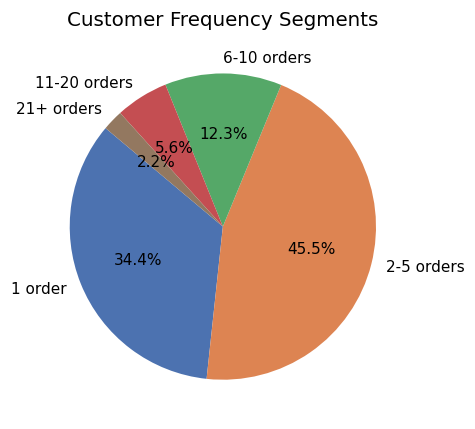

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
wedges, texts, autotexts = ax.pie(
    df_freq["customers"], labels=df_freq["segment"],
    autopct="%1.1f%%", startangle=140,
    colors=[COLORS["bar"], COLORS["line"], COLORS["accent"],
            COLORS["cancel"], "#937860"]
)
ax.set_title("Customer Frequency Segments")
plt.tight_layout()
plt.show()

---
## 17 — RFM snapshot (Recency, Frequency, Monetary)

A lightweight RFM analysis using SQL window-function quartiles.

In [26]:
con.sql("""
    WITH rfm_raw AS (
        SELECT
            CustomerID,
            -- days since last purchase (relative to dataset max date)
            DATE_DIFF('day',
                MAX(InvoiceDate),
                (SELECT MAX(InvoiceDate) FROM clean)
            ) AS recency,
            COUNT(DISTINCT InvoiceNo)   AS frequency,
            ROUND(SUM(TotalPrice), 2)   AS monetary
        FROM clean
        WHERE CustomerID != 0
        GROUP BY CustomerID
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(4) OVER (ORDER BY recency   DESC) AS r_score,  -- lower recency = better
            NTILE(4) OVER (ORDER BY frequency  ASC) AS f_score,
            NTILE(4) OVER (ORDER BY monetary   ASC) AS m_score
        FROM rfm_raw
    )
    SELECT
        r_score || '-' || f_score || '-' || m_score AS rfm,
        CASE
            WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Champions'
            WHEN r_score >= 3 AND f_score >= 2                  THEN 'Loyal'
            WHEN r_score >= 3                                   THEN 'Recent'
            WHEN f_score >= 3                                   THEN 'Frequent'
            WHEN m_score >= 3                                   THEN 'Big Spenders'
            WHEN r_score <= 1 AND f_score <= 1                  THEN 'At Risk'
            ELSE 'Other'
        END AS segment,
        COUNT(*)                    AS customers,
        ROUND(AVG(monetary), 2)     AS avg_monetary,
        ROUND(AVG(frequency), 1)    AS avg_frequency,
        ROUND(AVG(recency), 0)      AS avg_recency_days
    FROM rfm_scored
    GROUP BY segment, rfm
    ORDER BY customers DESC
    LIMIT 15
""").show()

┌─────────┬───────────┬───────────┬──────────────┬───────────────┬──────────────────┐
│   rfm   │  segment  │ customers │ avg_monetary │ avg_frequency │ avg_recency_days │
│ varchar │  varchar  │   int64   │    double    │    double     │      double      │
├─────────┼───────────┼───────────┼──────────────┼───────────────┼──────────────────┤
│ 4-4-4   │ Champions │       482 │      9196.73 │          15.6 │              7.0 │
│ 1-1-1   │ At Risk   │       442 │       165.49 │           1.0 │            267.0 │
│ 3-4-4   │ Champions │       231 │      5146.88 │           9.2 │             30.0 │
│ 1-1-2   │ At Risk   │       220 │       414.12 │           1.0 │            261.0 │
│ 3-2-1   │ Loyal     │       185 │       185.89 │           1.2 │             31.0 │
│ 3-3-3   │ Champions │       181 │      1064.43 │           3.2 │             30.0 │
│ 2-1-1   │ Other     │       179 │       173.81 │           1.0 │             88.0 │
│ 4-3-3   │ Champions │       151 │      1056.02 │    

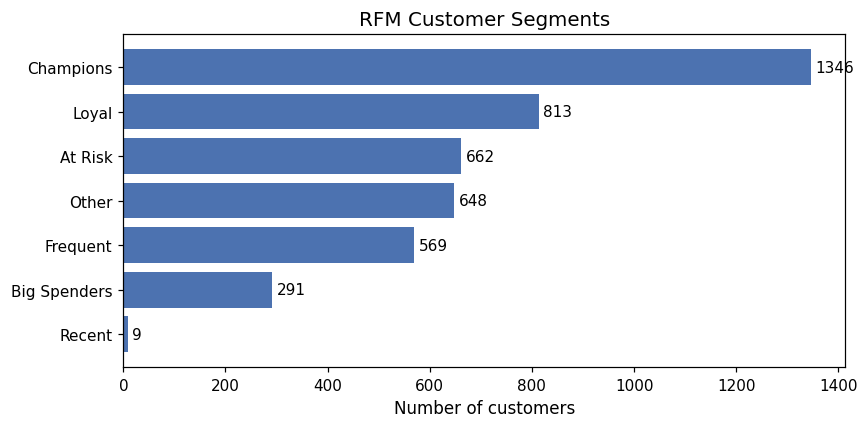

In [27]:
# segment summary
df_rfm_seg = con.sql("""
    WITH rfm_raw AS (
        SELECT
            CustomerID,
            DATE_DIFF('day',
                MAX(InvoiceDate),
                (SELECT MAX(InvoiceDate) FROM clean)
            ) AS recency,
            COUNT(DISTINCT InvoiceNo) AS frequency,
            ROUND(SUM(TotalPrice), 2) AS monetary
        FROM clean
        WHERE CustomerID != 0
        GROUP BY CustomerID
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(4) OVER (ORDER BY recency   DESC) AS r_score,
            NTILE(4) OVER (ORDER BY frequency  ASC) AS f_score,
            NTILE(4) OVER (ORDER BY monetary   ASC) AS m_score
        FROM rfm_raw
    ),
    segmented AS (
        SELECT *,
            CASE
                WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Champions'
                WHEN r_score >= 3 AND f_score >= 2                  THEN 'Loyal'
                WHEN r_score >= 3                                   THEN 'Recent'
                WHEN f_score >= 3                                   THEN 'Frequent'
                WHEN m_score >= 3                                   THEN 'Big Spenders'
                WHEN r_score <= 1 AND f_score <= 1                  THEN 'At Risk'
                ELSE 'Other'
            END AS segment
        FROM rfm_scored
    )
    SELECT
        segment,
        COUNT(*)                 AS customers,
        ROUND(AVG(monetary), 2)  AS avg_spend,
        ROUND(AVG(frequency), 1) AS avg_orders,
        ROUND(AVG(recency), 0)   AS avg_recency
    FROM segmented
    GROUP BY segment
    ORDER BY customers DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_rfm_seg["segment"][::-1], df_rfm_seg["customers"][::-1],
               color=COLORS["bar"])
ax.set_title("RFM Customer Segments")
ax.set_xlabel("Number of customers")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

---
## 18 — Revenue concentration (Pareto / 80-20 rule)

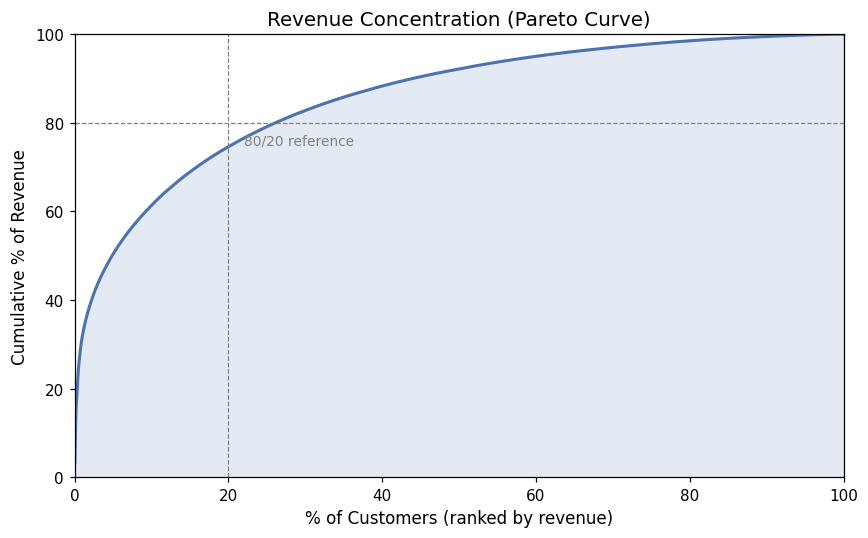

In [28]:
df_pareto = con.sql("""
    WITH cust_rev AS (
        SELECT  CustomerID,
                SUM(TotalPrice) AS revenue
        FROM clean
        WHERE CustomerID != 0
        GROUP BY CustomerID
    ),
    ranked AS (
        SELECT  *,
                ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
                COUNT(*) OVER ()                          AS total_cust
        FROM cust_rev
    )
    SELECT
        ROUND(100.0 * rn / total_cust, 2) AS pct_customers,
        ROUND(100.0 * SUM(revenue) OVER (ORDER BY revenue DESC)
              / SUM(revenue) OVER (), 2)  AS cumulative_revenue_pct
    FROM ranked
    ORDER BY rn
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_pareto["pct_customers"], df_pareto["cumulative_revenue_pct"],
        color=COLORS["bar"], linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(20, color="gray", linestyle="--", linewidth=0.8)
ax.fill_between(df_pareto["pct_customers"], df_pareto["cumulative_revenue_pct"],
                alpha=0.15, color=COLORS["bar"])
ax.set_title("Revenue Concentration (Pareto Curve)")
ax.set_xlabel("% of Customers (ranked by revenue)")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.text(22, 75, "80/20 reference", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

---
## 19 — Daily revenue time-series with 7-day moving average

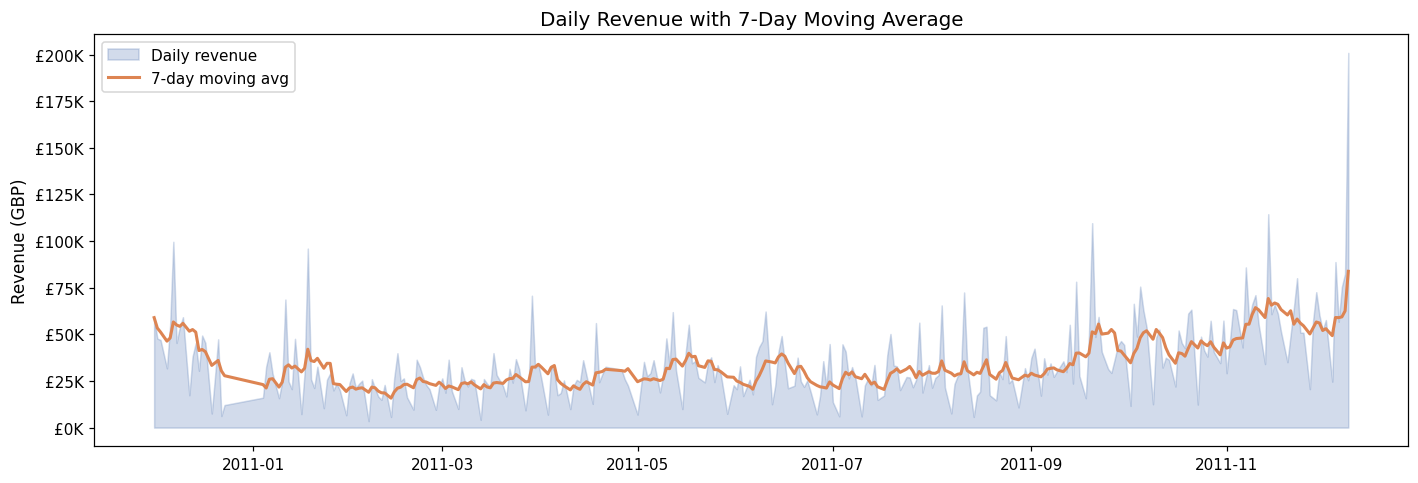

In [29]:
df_daily = con.sql("""
    SELECT
        InvoiceDay                            AS day,
        ROUND(SUM(TotalPrice), 2)             AS revenue,
        ROUND(AVG(SUM(TotalPrice)) OVER (
            ORDER BY InvoiceDay
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ), 2)                                 AS ma_7d
    FROM clean
    GROUP BY InvoiceDay
    ORDER BY InvoiceDay
""").df()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(df_daily["day"], df_daily["revenue"],
                alpha=0.25, color=COLORS["bar"], label="Daily revenue")
ax.plot(df_daily["day"], df_daily["ma_7d"],
        color=COLORS["line"], linewidth=2, label="7-day moving avg")
ax.set_title("Daily Revenue with 7-Day Moving Average")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 20 — UK vs. International revenue share over time

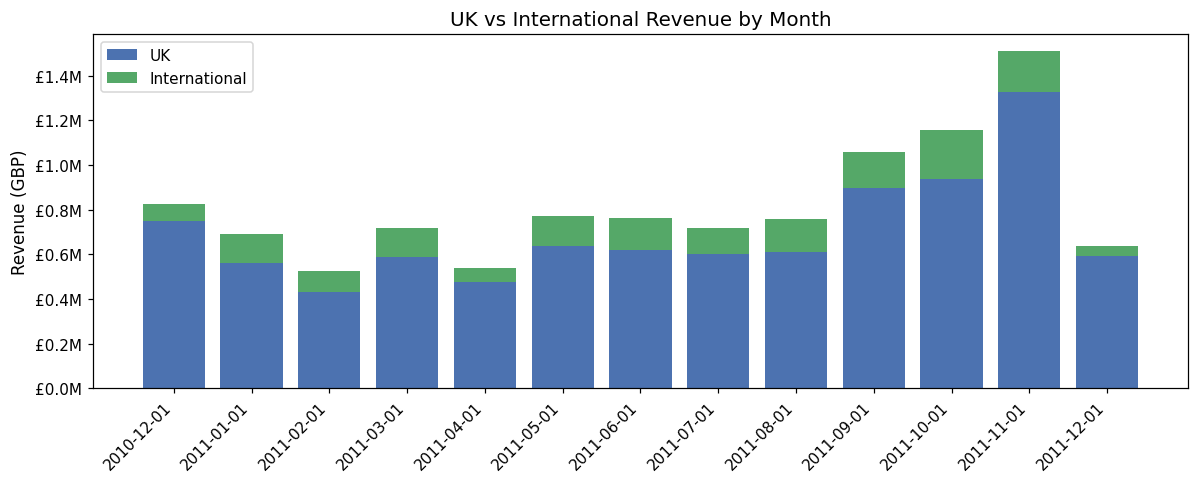

In [30]:
df_uk = con.sql("""
    SELECT
        InvoiceMonth AS month,
        ROUND(SUM(TotalPrice) FILTER
            (WHERE Country = 'United Kingdom'), 2)    AS uk_revenue,
        ROUND(SUM(TotalPrice) FILTER
            (WHERE Country != 'United Kingdom'), 2)   AS intl_revenue
    FROM clean
    GROUP BY InvoiceMonth
    ORDER BY InvoiceMonth
""").df()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(df_uk["month"].astype(str), df_uk["uk_revenue"],
       label="UK", color=COLORS["bar"])
ax.bar(df_uk["month"].astype(str), df_uk["intl_revenue"],
       bottom=df_uk["uk_revenue"],
       label="International", color=COLORS["accent"])
ax.set_title("UK vs International Revenue by Month")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

---
## 21 — Unit-price distribution (log scale)

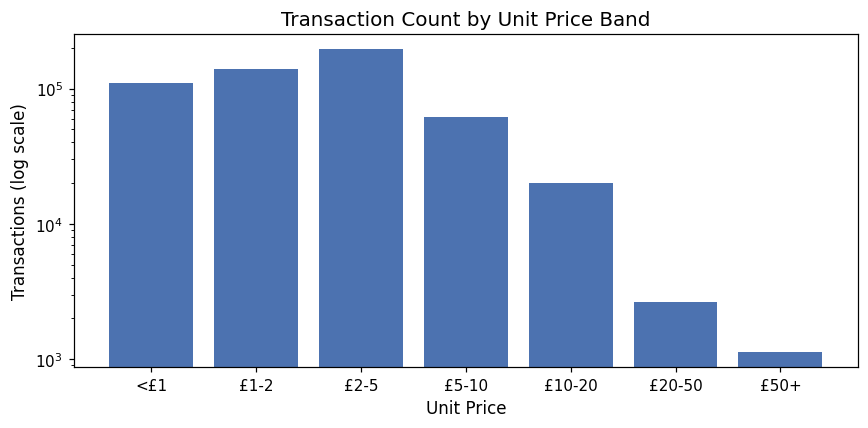

In [31]:
df_price_dist = con.sql("""
    SELECT
        CASE
            WHEN UnitPrice < 1    THEN '<£1'
            WHEN UnitPrice < 2    THEN '£1-2'
            WHEN UnitPrice < 5    THEN '£2-5'
            WHEN UnitPrice < 10   THEN '£5-10'
            WHEN UnitPrice < 20   THEN '£10-20'
            WHEN UnitPrice < 50   THEN '£20-50'
            ELSE '£50+'
        END AS price_band,
        COUNT(*)          AS transactions,
        SUM(Quantity)     AS total_units
    FROM clean
    GROUP BY price_band
    ORDER BY MIN(UnitPrice)
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_price_dist["price_band"], df_price_dist["transactions"],
       color=COLORS["bar"])
ax.set_title("Transaction Count by Unit Price Band")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Transactions (log scale)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

---
## 22 — Monthly cohort: new vs returning customers

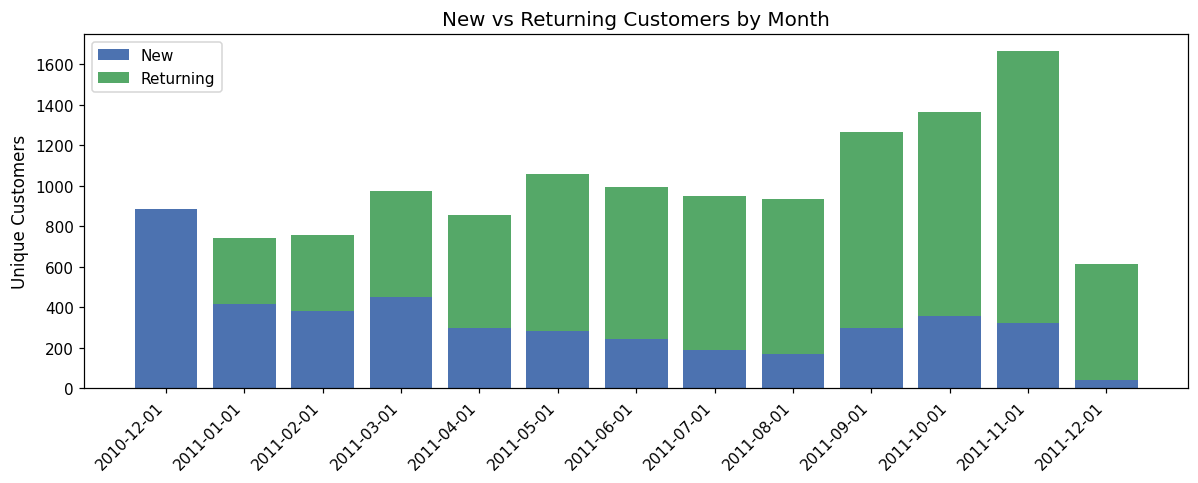

In [32]:
df_cohort = con.sql("""
    WITH first_purchase AS (
        SELECT CustomerID,
               MIN(InvoiceMonth) AS cohort_month
        FROM clean
        WHERE CustomerID != 0
        GROUP BY CustomerID
    ),
    monthly_activity AS (
        SELECT DISTINCT
               c.CustomerID,
               c.InvoiceMonth AS activity_month,
               f.cohort_month
        FROM clean c
        JOIN first_purchase f USING (CustomerID)
        WHERE c.CustomerID != 0
    )
    SELECT
        activity_month                                          AS month,
        COUNT(*) FILTER (WHERE activity_month = cohort_month)   AS new_customers,
        COUNT(*) FILTER (WHERE activity_month != cohort_month)  AS returning_customers
    FROM monthly_activity
    GROUP BY activity_month
    ORDER BY activity_month
""").df()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(df_cohort["month"].astype(str), df_cohort["new_customers"],
       label="New", color=COLORS["bar"])
ax.bar(df_cohort["month"].astype(str), df_cohort["returning_customers"],
       bottom=df_cohort["new_customers"],
       label="Returning", color=COLORS["accent"])
ax.set_title("New vs Returning Customers by Month")
ax.set_ylabel("Unique Customers")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

---
## 23 — Products frequently bought together (association pairs)

Self-join invoices to find the most common product co-occurrences.

In [33]:
con.sql("""
    WITH invoice_products AS (
        SELECT DISTINCT InvoiceNo, Description
        FROM clean
        WHERE Description != 'Unknown'
    )
    SELECT
        a.Description AS product_a,
        b.Description AS product_b,
        COUNT(*)      AS co_occurrences
    FROM invoice_products a
    JOIN invoice_products b
      ON a.InvoiceNo = b.InvoiceNo
     AND a.Description < b.Description      -- avoid duplicates & self-joins
    GROUP BY a.Description, b.Description
    ORDER BY co_occurrences DESC
    LIMIT 10
""").show()

┌─────────────────────────────────┬───────────────────────────────────┬────────────────┐
│            product_a            │             product_b             │ co_occurrences │
│             varchar             │              varchar              │     int64      │
├─────────────────────────────────┼───────────────────────────────────┼────────────────┤
│ JUMBO BAG PINK POLKADOT         │ JUMBO BAG RED RETROSPOT           │            825 │
│ GREEN REGENCY TEACUP AND SAUCER │ ROSES REGENCY TEACUP AND SAUCER   │            767 │
│ JUMBO BAG RED RETROSPOT         │ JUMBO STORAGE BAG SUKI            │            724 │
│ JUMBO BAG RED RETROSPOT         │ JUMBO SHOPPER VINTAGE RED PAISLEY │            680 │
│ LUNCH BAG  BLACK SKULL.         │ LUNCH BAG RED RETROSPOT           │            641 │
│ ALARM CLOCK BAKELIKE GREEN      │ ALARM CLOCK BAKELIKE RED          │            640 │
│ GREEN REGENCY TEACUP AND SAUCER │ PINK REGENCY TEACUP AND SAUCER    │            632 │
│ LUNCH BAG PINK POLK

---
## 24 — Summary of SQL concepts demonstrated

| SQL Feature | Where Used |
|---|---|
| `st_read()` (spatial extension) | §2 — native XLSX loading |
| `CREATE TABLE … AS SELECT` | §7 — data cleaning |
| `COALESCE`, `CASE WHEN` | §7 — null handling & bucketing |
| `GROUP BY` + aggregates | Throughout — counts, sums, averages |
| `DATE_TRUNC`, `EXTRACT` | §9, §13 — time-series & temporal |
| `FILTER (WHERE …)` | §6, §20, §22 — conditional aggregates |
| `LAG()` window function | §9 — month-over-month growth |
| `NTILE()` window function | §17 — RFM quartile scoring |
| `SUM() OVER (ORDER BY …)` | §18 — running cumulative totals |
| Moving-window frame | §19 — 7-day moving average |
| CTE (`WITH … AS`) | §14, §16–§18, §22–§23 |
| Self-join | §23 — market basket pairs |
| `ROW_NUMBER()`, `PERCENT_RANK()` | §18 — Pareto curve |

### Key business insights

1. **Revenue peaks** in Sep–Nov, driven by holiday buying.
2. The **UK dominates** (~85 % of revenue), but international AOV can be higher.
3. **~25 % of rows** lack a CustomerID — a data-quality gap worth investigating.
4. Revenue follows the **Pareto principle**: a small share of customers drives most revenue.
5. **Weekday mornings** (10–12 h) are the busiest ordering window.
6. Cancellation rates hover around **2–3 %** of invoices per month.

---
*Notebook authored for Data Warehousing — Week 3: Classic Data Warehousing.*

In [34]:
con.close()
print("DuckDB connection closed.  ✓")

DuckDB connection closed.  ✓
